# RE Run Comparison

Compares the **gold RE-only** runs (gold-standard EL input, temperature 0.0,
default thinking mode) recorded in `re-evaluation/scores.csv` — the set produced
by `run_re_gold_models.py`.

Two deliverables:
1. A heatmap of **binary F1** (JSON-derived vs RDF-derived) across models.
2. A pandas table with gs count / TP / FP / FN / P / R / F1 for the **best model
   per label** (IN, NEAR, THRU, TO, FROM), recomputed from that model's
   `events.json` via `re_evaluate.evaluate_fine_grained`.

`scores.csv` stores only per-label F1 (not TP/FP/FN/P/R), so the per-label
table recomputes by loading each best model's run through the existing
`re_evaluate` functions.

In [31]:
import sys, os, importlib.util
from pathlib import Path
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Resolve project root: this notebook lives in relation_extraction/, so its
# parent is the repo root (mirrors re_error_analysis.ipynb).
notebook_dir = Path(os.path.abspath("")).resolve()
project_root = notebook_dir.parent if notebook_dir.name == "relation_extraction" else notebook_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Load re_evaluate from its file path (no package import needed).
_re_eval_path = project_root / "relation_extraction" / "re_evaluate.py"
_spec = importlib.util.spec_from_file_location("re_evaluate", _re_eval_path)
_re_eval = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_re_eval)

load_gold_standard = _re_eval.load_gold_standard
load_mention_map = _re_eval.load_mention_map
load_events = _re_eval.load_events
derive_predictions = _re_eval.derive_predictions
evaluate_fine_grained = _re_eval.evaluate_fine_grained
extract_model_from_filename = _re_eval.extract_model_from_filename

SCORES_CSV = project_root / "relation_extraction" / "re-evaluation" / "scores.csv"
GOLD_CSV = project_root / "relation_extraction" / "1816_re_gs.csv"
OUTPUT_RE = project_root / "output" / "re"
FIG_DIR = project_root / "relation_extraction" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

# RE output filenames slug the model (colon -> underscore), so scores.csv's
# `model` column holds the slug form (e.g. "gemma4_31b"). Key the palette by
# those slugs (the EL notebook uses colon form; RE differs here).
MODEL_COLORS = {
    "deepseek-v4-flash": "#0b6aae",
    "deepseek-v4-pro": "#287f8c",
    "gemma4_31b": "#af200d",
    "glm-5.1": "#e07b39",
    "glm-5.2": "#c0392b",
    "kimi-k2.7-code": "#842cbe",
    "mistral-large-3_675b": "#2e8b57",
    "qwen3.5_397b": "#b8860b",
}

LABELS = ["IN", "NEAR", "THRU", "TO", "FROM"]
LABEL_COL = {"IN": "in_f1", "NEAR": "near_f1", "THRU": "thru_f1",
             "TO": "to_f1", "FROM": "from_f1"}

print(f"Project root: {project_root}")
print(f"scores.csv:   {SCORES_CSV}")
print("Imports OK")

Project root: /home/tijn-do/github/hist-dutch-travelogues-nlp
scores.csv:   /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/re-evaluation/scores.csv
Imports OK


## 1. Load and filter `scores.csv`

Keep one row per (source, model, temperature, think_mode). `keep='last'`
retains the most recent eval, which ran against the `events.json` currently
on disk (the orchestrator extracts then immediately scores each model), so
the later recomputation cross-check is valid. Then filter to the gold
RE-only scope: `source_text == '1816_el_gs'`, `temperature == 0.0`,
`think_mode == 'default'`.

In [32]:
df = pd.read_csv(SCORES_CSV)

df = df.drop_duplicates(
    subset=["source_text", "model", "temperature", "think_mode"], keep="last"
)

mask = (
    (df["source_text"] == "1816_el_gs")
    & (df["temperature"].astype(float) == 0.0)
    & (df["think_mode"] == "default")
)
gold = df[mask].copy().reset_index(drop=True)

cols = ["model", "binary_json_f1", "binary_rdf_f1",
        "in_f1", "near_f1", "thru_f1", "to_f1", "from_f1", "duration_seconds"]
print(f"{len(gold)} gold RE-only run(s) @ t=0.0/default "
      f"(depends on run_re_gold_models.py having been executed)")
gold[cols]

8 gold RE-only run(s) @ t=0.0/default (depends on run_re_gold_models.py having been executed)


,model,binary_json_f1,binary_rdf_f1,in_f1,near_f1,thru_f1,to_f1,from_f1,duration_seconds
0,gemma4_31b,0.818,0.492,0.625,0.340,0.444,0.727,0.667,73.8
1,deepseek-v4-flash,0.879,0.610,0.641,0.316,0.500,0.000,0.400,208.9
2,mistral-large-3_675b,0.896,0.526,0.712,0.275,0.414,0.222,0.667,161.6
3,qwen3.5_397b,0.867,0.393,0.709,0.364,0.421,0.200,0.571,79.9
4,kimi-k2.7-code,0.656,0.590,0.566,0.373,0.545,0.000,0.667,419.1
5,glm-5.1,0.924,0.711,0.748,0.357,0.435,0.909,0.571,620.6
6,glm-5.2,0.839,0.620,0.610,0.333,0.500,0.909,0.667,750.2
7,deepseek-v4-pro,0.899,0.785,0.683,0.379,0.560,0.250,0.667,345.6


## 2. Binary F1 heatmap

Models (rows) × {binary JSON F1, binary RDF F1} (columns). Rows ordered by
descending JSON F1; row labels coloured by the model palette.

saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/re_binary_f1_heatmap.png


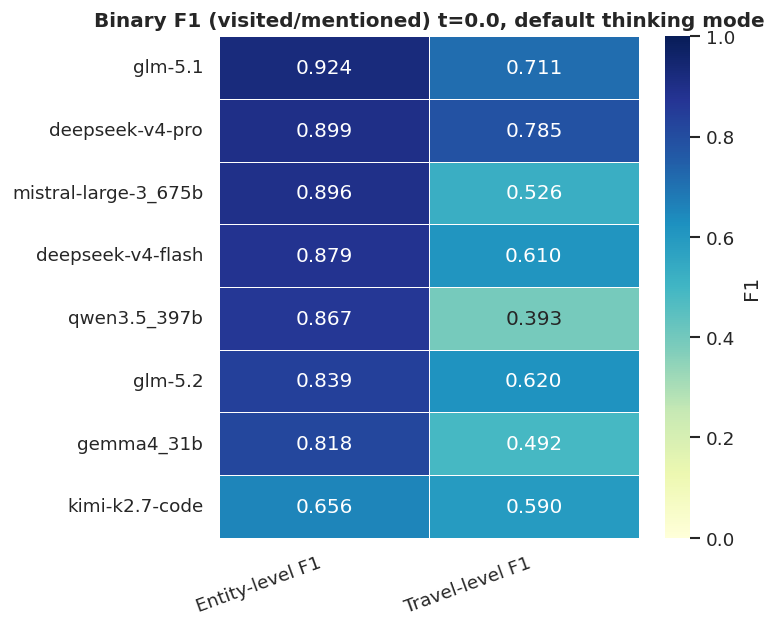


Raw values:


,Entity-level F1,Travel-level F1
model,,
glm-5.1,0.924,0.711
deepseek-v4-pro,0.899,0.785
mistral-large-3_675b,0.896,0.526
deepseek-v4-flash,0.879,0.610
qwen3.5_397b,0.867,0.393
glm-5.2,0.839,0.620
gemma4_31b,0.818,0.492
kimi-k2.7-code,0.656,0.590


In [33]:
pivot = (
    gold[["model", "binary_json_f1", "binary_rdf_f1"]]
    .set_index("model")
    .rename(columns={"binary_json_f1": "Entity-level F1",
                     "binary_rdf_f1": "Travel-level F1"})
)
pivot = pivot.sort_values("Entity-level F1", ascending=False)

fig, ax = plt.subplots(figsize=(6.5, max(2.0, len(pivot) * 0.55 + 1)))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="YlGnBu",
    vmin=0, vmax=1, linewidths=0.5,
    cbar_kws={"label": "F1"}, ax=ax,
)
ax.set_title("Binary F1 (visited/mentioned) t=0.0, default thinking mode",
             fontsize=12, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
save_fig(fig, "re_binary_f1_heatmap")
plt.show()

print("\nRaw values:")
display(pivot.round(3))

## 3. Per-label F1 heatmap

Models (rows) × relation labels (columns: IN, THRU, FROM, TO, NEAR), cell
value = per-label F1 from `scores.csv`. The leading **TOTAL (micro)** column
is the micro-averaged F1 (`fine_micro_f1`) — `total_TP / total_entities`,
i.e. accuracy where **each entity is counted equally** across all six Soni
labels (incl. NO_REL). This is *not* the macro F1 (which weights every
category equally regardless of size). Rows ordered by TOTAL (micro)
descending; row labels coloured by the model palette.

saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/re_per_label_f1_heatmap.png


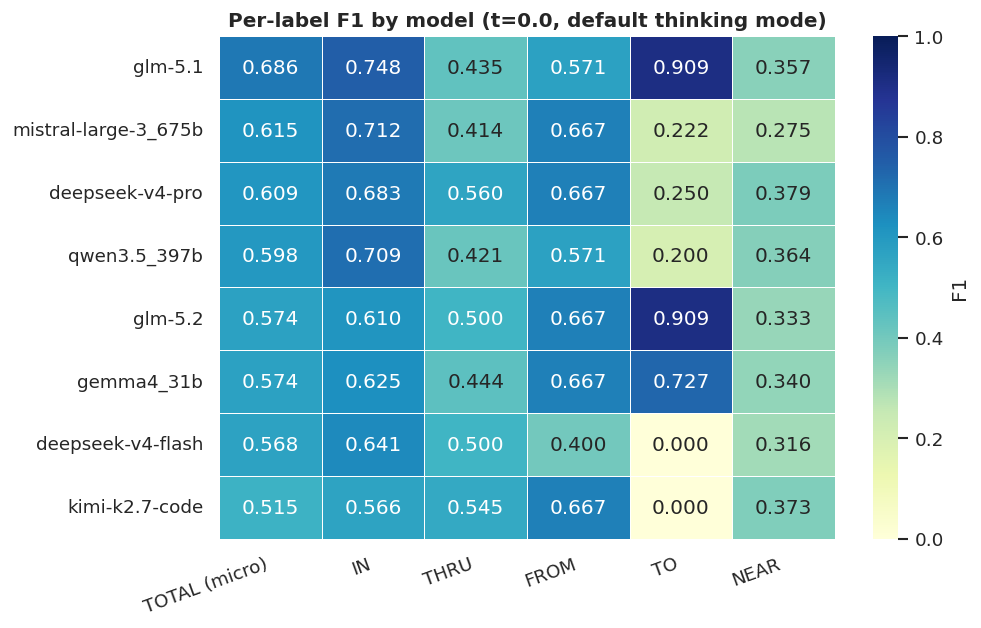


Raw values:


,TOTAL (micro),IN,THRU,FROM,TO,NEAR
model,,,,,,
glm-5.1,0.686,0.748,0.435,0.571,0.909,0.357
mistral-large-3_675b,0.615,0.712,0.414,0.667,0.222,0.275
deepseek-v4-pro,0.609,0.683,0.560,0.667,0.250,0.379
qwen3.5_397b,0.598,0.709,0.421,0.571,0.200,0.364
glm-5.2,0.574,0.610,0.500,0.667,0.909,0.333
gemma4_31b,0.574,0.625,0.444,0.667,0.727,0.340
deepseek-v4-flash,0.568,0.641,0.500,0.400,0.000,0.316
kimi-k2.7-code,0.515,0.566,0.545,0.667,0.000,0.373


In [34]:
LABEL_ORDER = ["IN", "THRU", "FROM", "TO", "NEAR"]
TOTAL_COL = "TOTAL (micro)"

label_pivot = (
    gold[["model", "fine_micro_f1"] + [LABEL_COL[l] for l in LABEL_ORDER]]
    .set_index("model")
    .rename(columns={**{LABEL_COL[l]: l for l in LABEL_ORDER},
                      "fine_micro_f1": TOTAL_COL})
)
# TOTAL (micro) first, then per-label columns.
label_pivot = label_pivot[[TOTAL_COL] + LABEL_ORDER]
# Order rows by the micro total (each entity counted equally), descending.
label_pivot = label_pivot.loc[label_pivot[TOTAL_COL].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, max(2.0, len(label_pivot) * 0.55 + 1)))
sns.heatmap(
    label_pivot, annot=True, fmt=".3f", cmap="YlGnBu",
    vmin=0, vmax=1, linewidths=0.5,
    cbar_kws={"label": "F1"}, ax=ax,
)
ax.set_title("Per-label F1 by model (t=0.0, default thinking mode)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
save_fig(fig, "re_per_label_f1_heatmap")
plt.show()

print("\nRaw values:")
display(label_pivot.round(3))

## 4. Best model per label

For each label, pick the model with the highest `{label}_f1` in the filtered
`scores.csv` (falling back to the next-best if that model's run is not on
disk), then **recompute** `evaluate_fine_grained` from its `events.json` +
`mention_map.json` to recover TP/FP/FN/P/R. A cross-check confirms the
recomputed F1 matches the `scores.csv` value for that run (a mismatch would
mean the on-disk run drifted from the scored row, or a wrong file-path join).

In [35]:
# (model, str(temp), think) -> {events, mention_map} by scanning output/re and
# parsing each filename with re_evaluate's own parser (single source of truth
# for the slug rules).
runs = {}
for p in sorted(OUTPUT_RE.glob("*_events.json")):
    model, temp, think = extract_model_from_filename(str(p))
    if model is None:
        continue
    stem = p.stem
    base = stem[:-7] if stem.endswith("_events") else stem
    mm = p.with_name(f"{base}_mention_map.json")
    key = (model, f"{float(temp)}", (think or "default").lower())
    runs[key] = {"events": p, "mention_map": mm}

gold_entities = load_gold_standard(str(GOLD_CSV))
gs_counts = Counter(g["visited_type"] for g in gold_entities)

def lookup_run(model):
    return runs.get((model, "0.0", "default"))

rows, crosscheck = [], []
for label in LABELS:
    col = LABEL_COL[label]
    ranked = gold.sort_values(col, ascending=False)
    best_model, best_row = None, None
    for _, r in ranked.iterrows():
        run = lookup_run(r["model"])
        if run and run["mention_map"].exists():
            best_model, best_row = r["model"], r
            break
    if best_model is None:
        print(f"  WARNING: {label} - no on-disk run among scored models")
        continue
    run = lookup_run(best_model)
    mm = load_mention_map(str(run["mention_map"]))
    ev = load_events(str(run["events"]))
    preds = derive_predictions(ev, mm)
    fine, _ = evaluate_fine_grained(gold_entities, preds, mm)
    c = fine[label]
    recomputed_f1 = c["f1"]
    scores_csv_f1 = float(best_row[col])
    rows.append({
        "label": label,
        "best_model": best_model,
        "gs_count": int(gs_counts.get(label, 0)),
        "TP": c["tp"], "FP": c["fp"], "FN": c["fn"],
        "P": c["precision"], "R": c["recall"], "F1": recomputed_f1,
    })
    crosscheck.append({
        "label": label, "best_model": best_model,
        "scores_csv_f1": scores_csv_f1, "recomputed_f1": recomputed_f1,
        "match": abs(scores_csv_f1 - recomputed_f1) < 1e-6,
    })

table = pd.DataFrame(rows)
print("Best model per label (highest F1 in scores.csv, recomputed from disk):\n")
display(table)

# Cross-check: recomputed per-label F1 must equal the scores.csv value for the
# same run. Soft check (does not raise) so a drifted on-disk run is surfaced,
# not fatal.
cc = pd.DataFrame(crosscheck)
mismatches = cc[~cc["match"]]
print(f"\nCross-check (recomputed vs scores.csv F1): "
      f"{len(cc) - len(mismatches)}/{len(cc)} match")
if len(mismatches):
    print("  mismatches (on-disk run differs from the scores.csv row):")
    display(mismatches)
else:
    print("  all recomputed F1 values match scores.csv - file-path join is correct.")

# Informational: TP+FN = matched gold of that label, which is <= gs_count when
# some gold entities did not overlap a mention_map span.
print("\nSanity (TP+FN vs gs_count; unmatched = gold of that label with no span match):")
sanity = table[["label", "TP", "FN", "gs_count"]].copy()
sanity["TP+FN"] = sanity["TP"] + sanity["FN"]
sanity["unmatched"] = sanity["gs_count"] - sanity["TP+FN"]
display(sanity)

Best model per label (highest F1 in scores.csv, recomputed from disk):



,label,best_model,gs_count,TP,FP,FN,P,R,F1
0,IN,glm-5.1,63,52,24,11,0.684,0.825,0.748
1,NEAR,deepseek-v4-pro,44,11,3,33,0.786,0.250,0.379
2,THRU,deepseek-v4-pro,9,7,9,2,0.438,0.778,0.560
3,TO,glm-5.2,6,5,0,1,1.000,0.833,0.909
4,FROM,gemma4_31b,4,2,0,2,1.000,0.500,0.667



Cross-check (recomputed vs scores.csv F1): 5/5 match
  all recomputed F1 values match scores.csv - file-path join is correct.

Sanity (TP+FN vs gs_count; unmatched = gold of that label with no span match):


,label,TP,FN,gs_count,TP+FN,unmatched
0,IN,52,11,63,63,0
1,NEAR,11,33,44,44,0
2,THRU,7,2,9,9,0
3,TO,5,1,6,6,0
4,FROM,2,2,4,4,0


## 5. Key findings

- **Best binary JSON F1**: see the heatmap's top row.
- **Best binary RDF F1**: compare the second column.
- **Per-label winners**: see the `best_model` column of the table above.
- Note any label with low recall (`R`) — those are categories the model
  misses (false negatives), i.e. visited toponyms it fails to classify.

Re-run after `run_re_gold_models.py` completes all 8 models for the full
comparison; this notebook re-reads `scores.csv` each time it runs.